In [64]:
from typing import List, Tuple
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
np.random.seed(1)

In [65]:
# Environment Definition (Already Implemented)

actions = {
    "up": (0, 1),
    "left": (-1, 0),
    "right": (1, 0),
    "down": (0, -1),
}

p_e = 1/3

def get_adjacent_positions(position: Tuple[int, int]) -> List[Tuple[int, int]]:
    x, y = position
    return [
            (x, y + 1),
            (x, y - 1),
            (x + 1, y),
            (x - 1, y),
    ]

class DungeonEnvironment:
    def __init__(self):
        self.start_pos = (0,0)
        self.goal_pos = (3,4)
        self.holes = [(0,4), (3,2)]
        self.walls = [(0,2), (2,0), (2,2), (2,3)]
        self.current_position = (0,0)

    def get_echo(self):
        for adjacent in get_adjacent_positions(self.current_position):
            if adjacent in self.holes:
                # hear an each with prob 1/3
                if np.random.random() < p_e:
                    return True
        return False

    def reset(self):
        """
        Called at the start of the game.
        """
        self.current_position = self.start_pos

    def step(self, action: str) -> Tuple[dict, str, bool]:
        """
        Updates the environment with the action of the agent.
        :returns: new observation for the agent, as well as if the game ended and the outcome.
        """
        act_x, act_y = actions[action]
        curr_x, curr_y = self.current_position

        new_x = curr_x + act_x
        new_y = curr_y + act_y

        # we bump if we go into a wall, or if we go out of bound
        if (new_x, new_y) in self.walls or not (0<=new_x<=4 and 0<=new_y<=4):
            bump = True
        else:
            # if we do not bump, update the position.
            bump = False
            self.current_position = (new_x, new_y)

        observation = {
            "echo" : self.get_echo(),
            "position": self.current_position,
        }

        if self.current_position == self.goal_pos:
            outcome = "Escaped"
            terminated = True
        elif self.current_position in self.holes:
            outcome = "Fell into hole"
            terminated = True

        else:
            outcome = None
            terminated = False

        return observation, outcome, terminated

In [66]:
# Belief State (To be completed)


class BeliefState:
    """
    Maintains what we believe, using the knowledge base.
    """
    def __init__(self, initial_hole_belief=0.5):
        possible_hole_positions = [(1, 2), (0,4), (3,2), (4, 0), (4,4)]
        # Belief about whether there is holes at the possible hole positions.
        self.hole_beliefs = {
            pos : initial_hole_belief
            for pos in possible_hole_positions
        } 
        self.current_position = (0, 0)

    def update(self, echo: bool, position: Tuple[int, int]):
        """
        :param echo: did we hear an echo ?
        :param position: our current position.
        """
        self.current_position = position
        
        new_belief = self.hole_beliefs.copy()

        for adjacent_pos in get_adjacent_positions(position):
            if adjacent_pos not in self.hole_beliefs:
                continue
            # We are adjacent to a hole position
            prior = self.hole_beliefs[adjacent_pos]

            # Set the likelihoods
            likelihood_hole = 1/3 if echo else 2/3 # Probability of echo given hole, or of no echo given hole
            likelihood_no_hole = 0 if echo else 1 # Probability of echo given no hole, or of no echo given no hole

            # Compute the evidence
            evidence = likelihood_hole * prior + likelihood_no_hole * (1-prior)

            # Update the belief using Bayes
            new_belief[adjacent_pos] = (likelihood_hole * prior) / evidence

        self.hole_beliefs = new_belief
        
        
    def visualise(self):
        grid_size = (5, 5)
        grid = np.zeros(grid_size)

        for x in range(5):
            for y in range(5):
                grid[y, x] = self.hole_beliefs.get((x,y), 0)

        plt.figure()
        plt.imshow(grid, cmap="viridis", origin="lower", extent=[0, 5, 0, 5])

        plt.colorbar(label="Hole probability")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.xticks(range(0, 6))
        plt.yticks(range(0, 6))
        plt.grid(True, linestyle="--", alpha=0.6, color="black")
        plt.title("Holes belief")
        plt.show()

In [67]:
# function for running any agent on the dungeon environment (Already implemented)
def play_game(policy, belief_state):
    terminated = False
    environment = DungeonEnvironment()
    environment.reset()
    num_steps = 0
    trajectory = []
    while not terminated:
        action = policy(belief_state)
        observation, outcome, terminated = environment.step(action)
        belief_state.update(**observation)
        trajectory.append(environment.current_position)
        num_steps += 1

        if num_steps >= 500:
            outcome = "Timeout"
            terminated = True
    
    return outcome, trajectory

In [68]:
# Agent definitions

# Naive agent Example 
def random_agent(belief) -> str:
    """
    This is a naive agent, picking actions randomly.
    """
    action_names = list(actions.keys())
    return np.random.choice(action_names)

# Smarter agent: 
def smarter_agent(belief) -> str:
    """
    This function selects a new action based on the belief state.
    :param belief: Current belief state.
    :return: action picked by the policy (e.g., "up"):
    """
    action_names = list(actions.keys())
    move = np.random.choice(action_names)

    curr_x, curr_y = belief.current_position
    act_x, act_y = actions[move]

    new_x = curr_x + act_x
    new_y = curr_y + act_y
    next_position = (new_x, new_y)
    
    if next_position in belief.hole_beliefs and belief.hole_beliefs[next_position] > 0.9:
        action_names.remove(move)
        # There's only one possible hole nearby so any other action will be safe. We'll just pick one
        # randomly here.
        move = np.random.choice(action_names)

    return move


Initial belief:


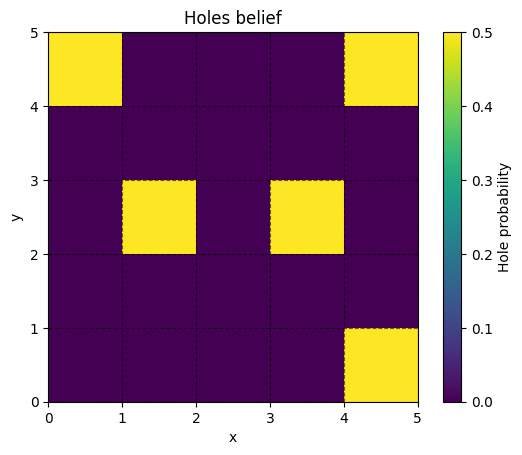

Episode 1:
The game ended in 36 steps with the following outcome: Escaped.
Belief:


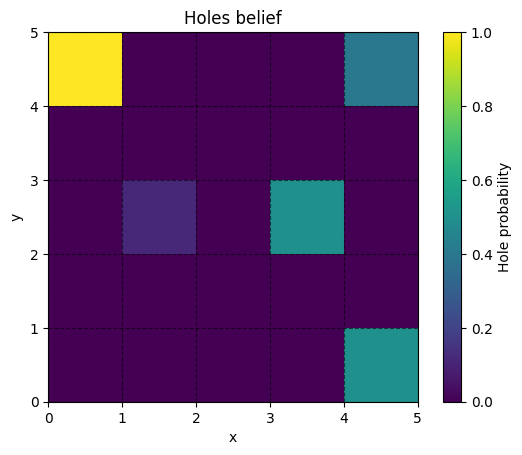

Episode 2:
The game ended in 45 steps with the following outcome: Escaped.
Belief:


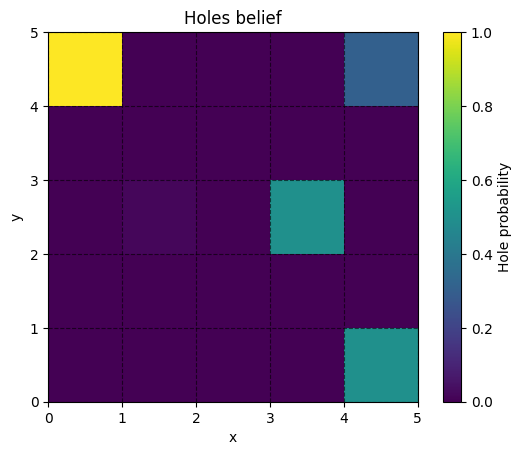

Episode 3:
The game ended in 53 steps with the following outcome: Fell into hole.
Belief:


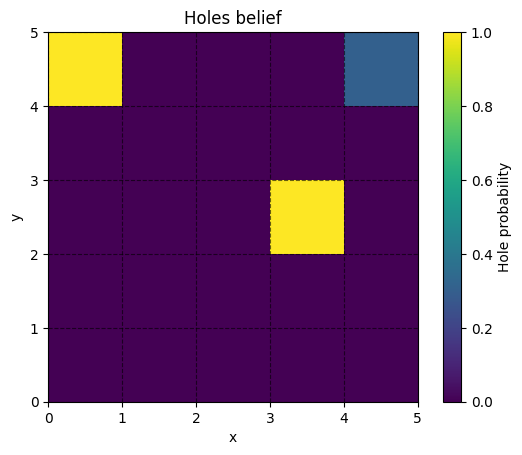

Episode 4:
The game ended in 20 steps with the following outcome: Fell into hole.
Belief:


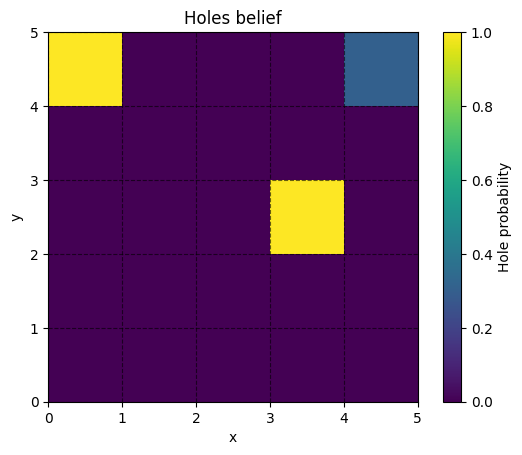

Episode 5:
The game ended in 100 steps with the following outcome: Escaped.
Belief:


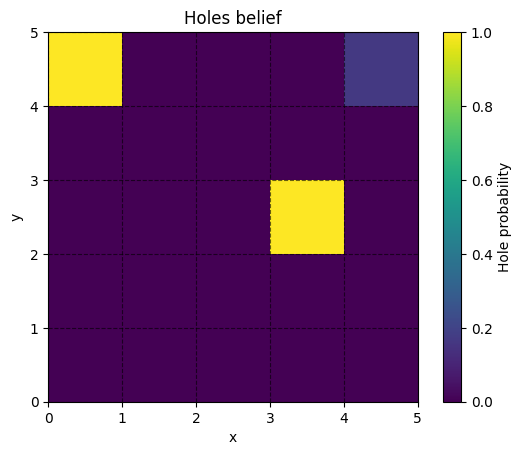

Episode 6:
The game ended in 39 steps with the following outcome: Fell into hole.
Belief:


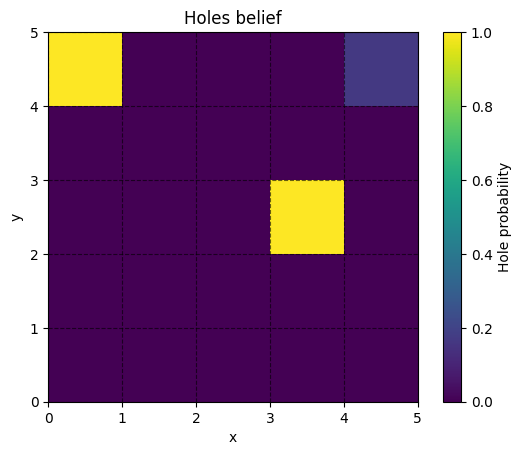

Episode 7:
The game ended in 29 steps with the following outcome: Fell into hole.
Belief:


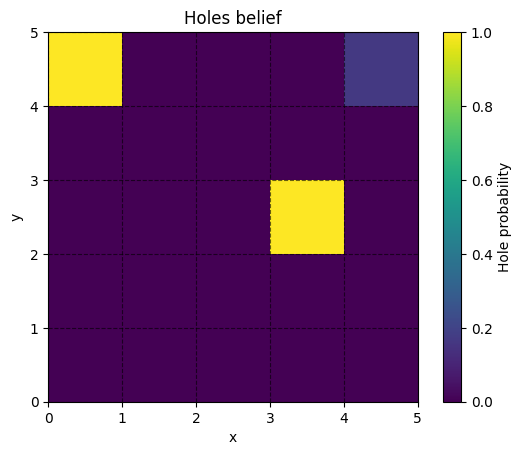

Episode 8:
The game ended in 53 steps with the following outcome: Fell into hole.
Belief:


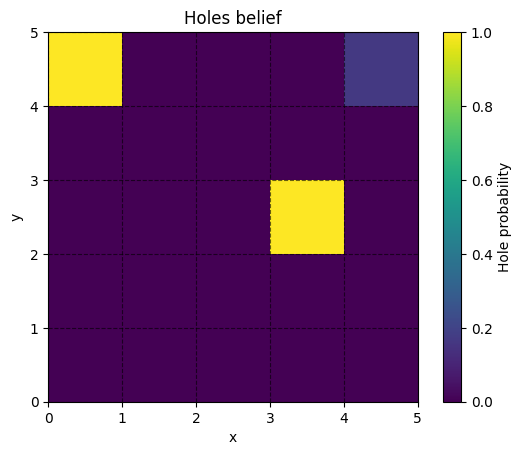

Episode 9:
The game ended in 22 steps with the following outcome: Fell into hole.
Belief:


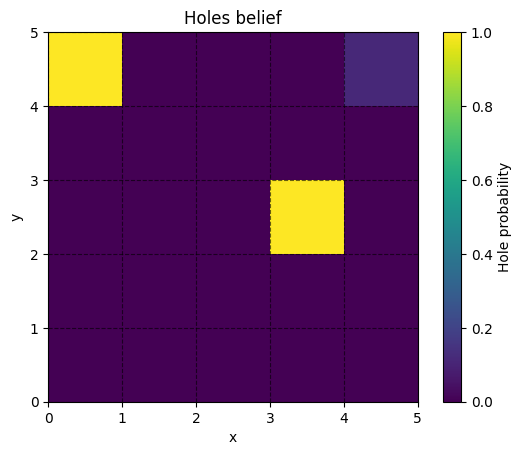

Episode 10:
The game ended in 30 steps with the following outcome: Fell into hole.
Belief:


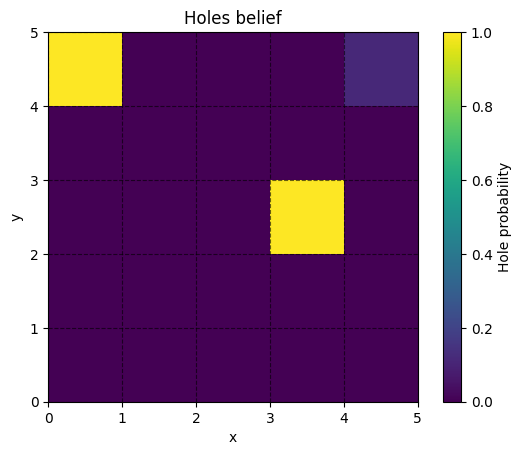

Episode 11:
The game ended in 18 steps with the following outcome: Fell into hole.
Belief:


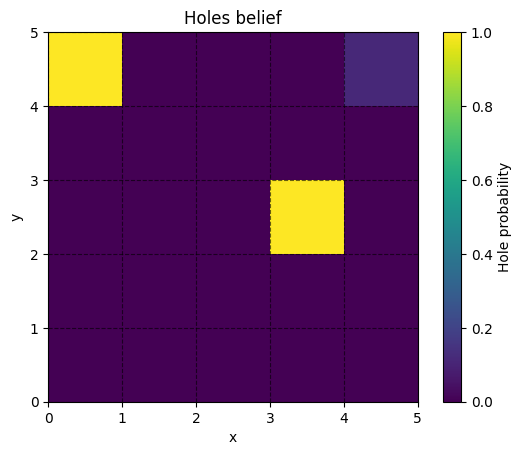

Episode 12:
The game ended in 17 steps with the following outcome: Fell into hole.
Belief:


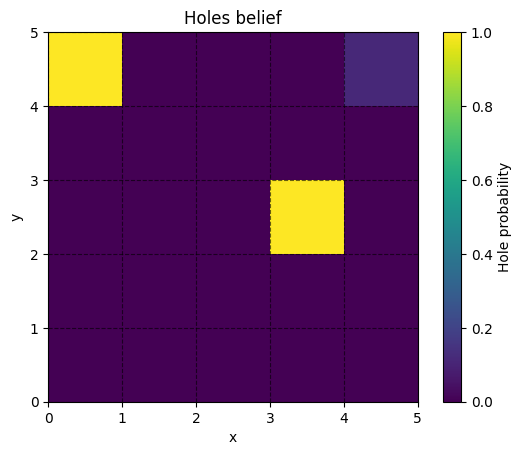

Episode 13:
The game ended in 28 steps with the following outcome: Fell into hole.
Belief:


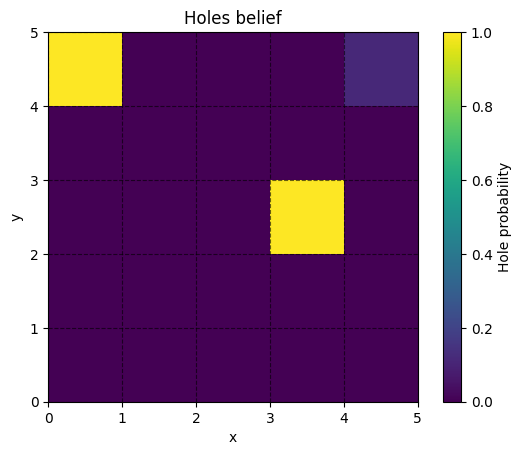

Episode 14:
The game ended in 26 steps with the following outcome: Escaped.
Belief:


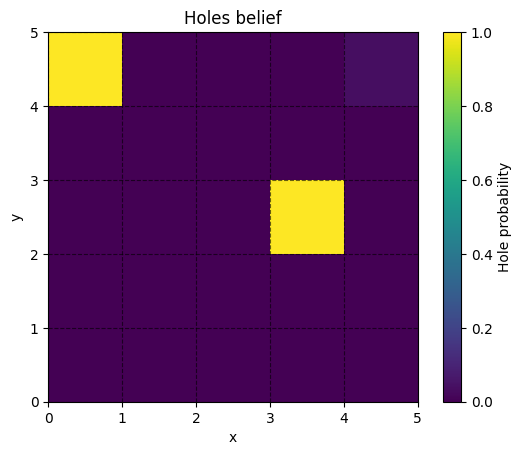

Episode 15:
The game ended in 41 steps with the following outcome: Fell into hole.
Belief:


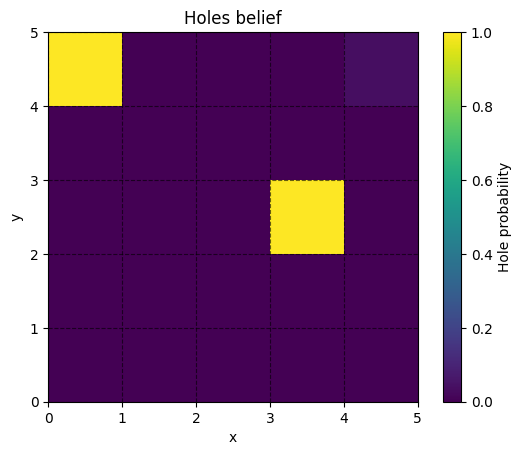

Episode 16:
The game ended in 34 steps with the following outcome: Fell into hole.
Belief:


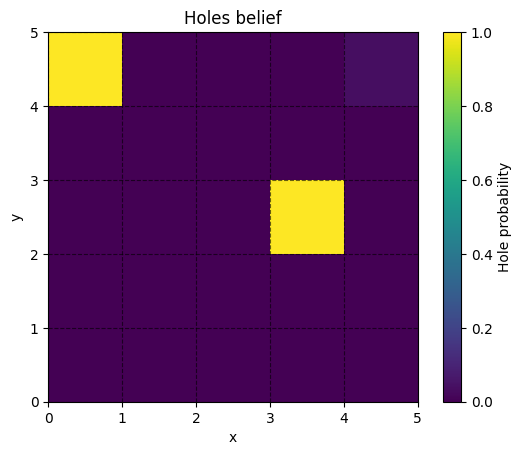

Episode 17:
The game ended in 59 steps with the following outcome: Fell into hole.
Belief:


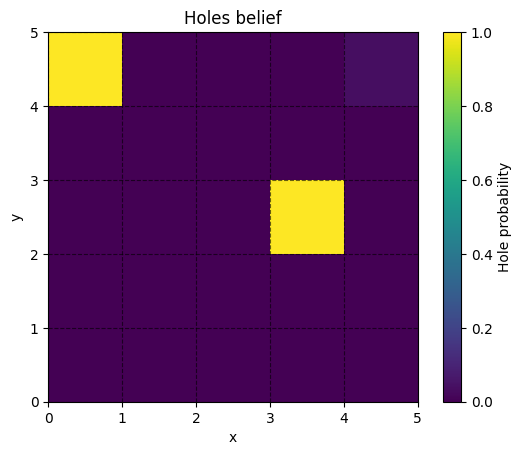

Episode 18:
The game ended in 64 steps with the following outcome: Escaped.
Belief:


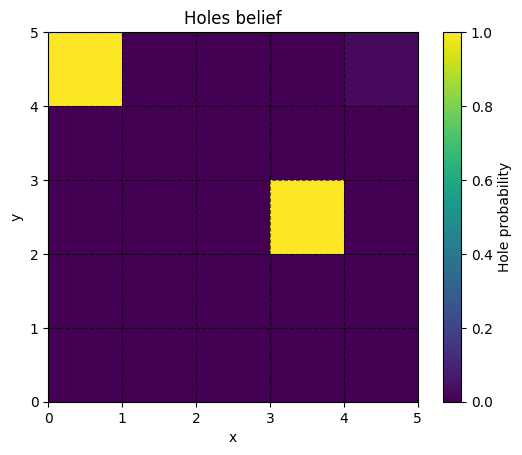

Episode 19:
The game ended in 8 steps with the following outcome: Escaped.
Belief:


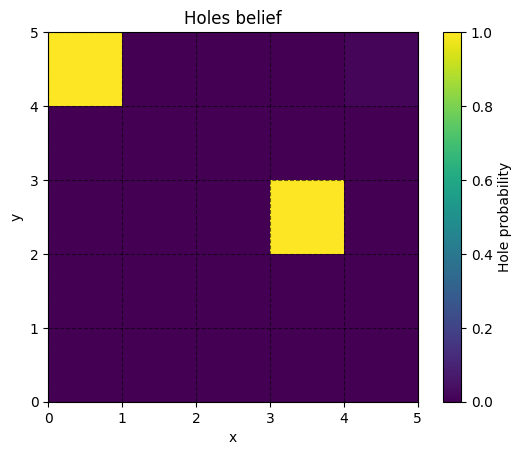

Episode 20:
The game ended in 84 steps with the following outcome: Fell into hole.
Belief:


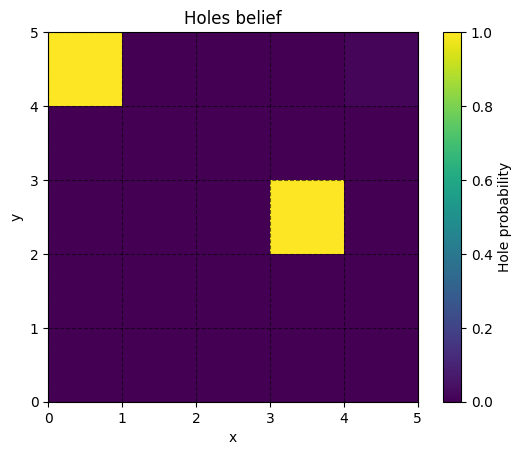

Escaped 6 times


In [69]:
belief_state = BeliefState()

print("Initial belief:")
belief_state.visualise()

escaped = 0

for episode in range(1, 21):
    outcome, trajectory = play_game(random_agent, belief_state)
    
    print(f"Episode {episode}:")
    print(f"The game ended in {len(trajectory)} steps with the following outcome: {outcome}.")
    
    print("Belief:")
    belief_state.visualise()

    if outcome == "Escaped":
        escaped += 1

print(f"Escaped {escaped} times")

Initial belief:


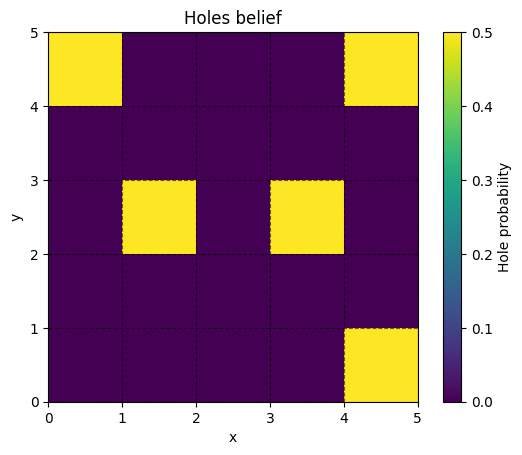

Episode 1:
The game ended in 102 steps with the following outcome: Escaped.
Belief:


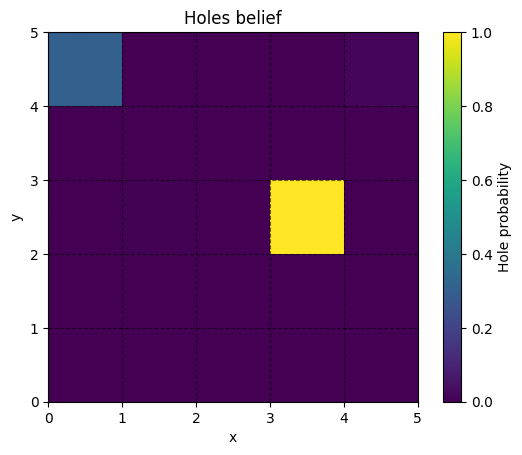

Episode 2:
The game ended in 239 steps with the following outcome: Escaped.
Belief:


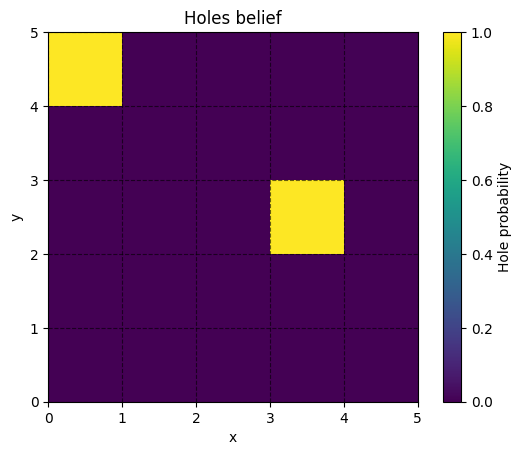

Episode 3:
The game ended in 54 steps with the following outcome: Escaped.
Belief:


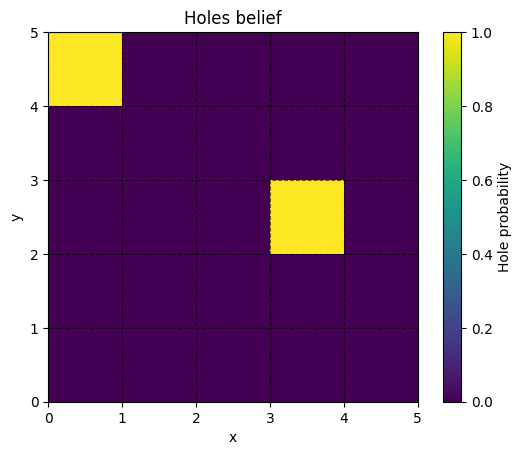

Episode 4:
The game ended in 66 steps with the following outcome: Escaped.
Belief:


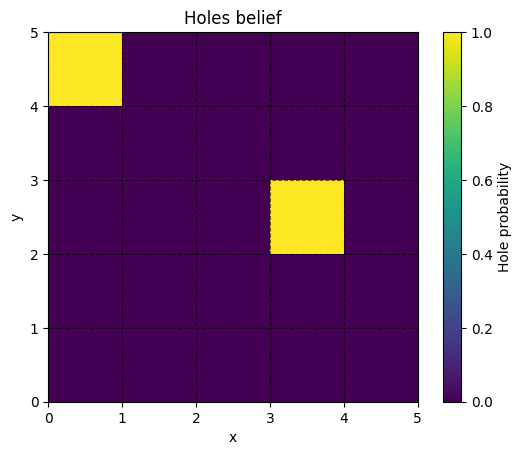

Episode 5:
The game ended in 48 steps with the following outcome: Escaped.
Belief:


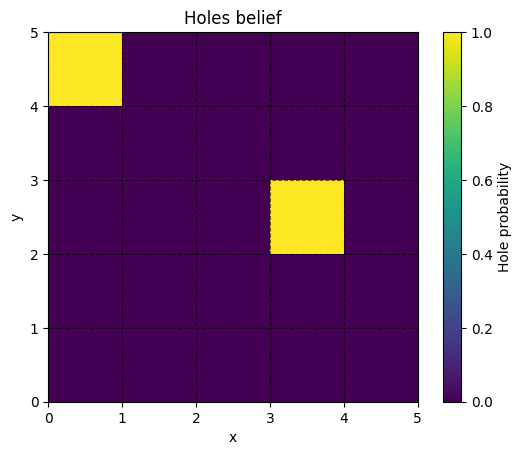

Episode 6:
The game ended in 105 steps with the following outcome: Escaped.
Belief:


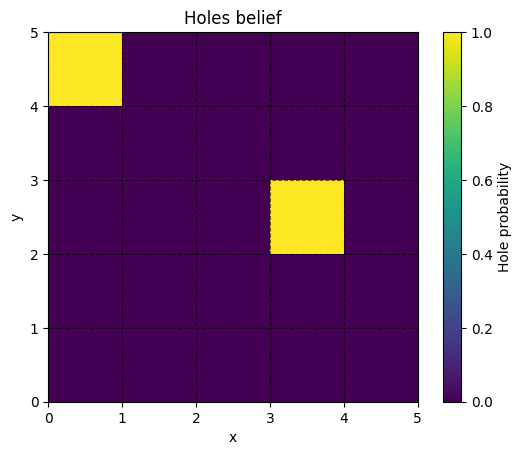

Episode 7:
The game ended in 128 steps with the following outcome: Escaped.
Belief:


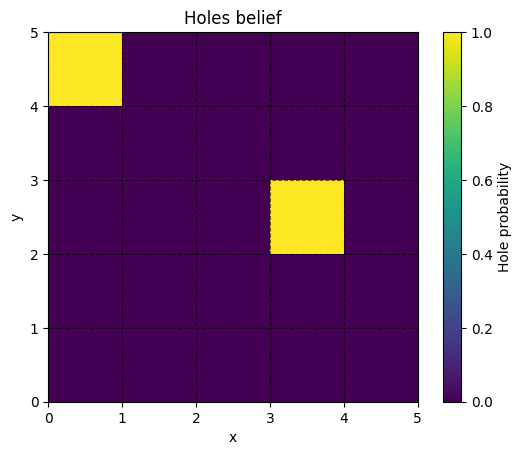

Episode 8:
The game ended in 40 steps with the following outcome: Escaped.
Belief:


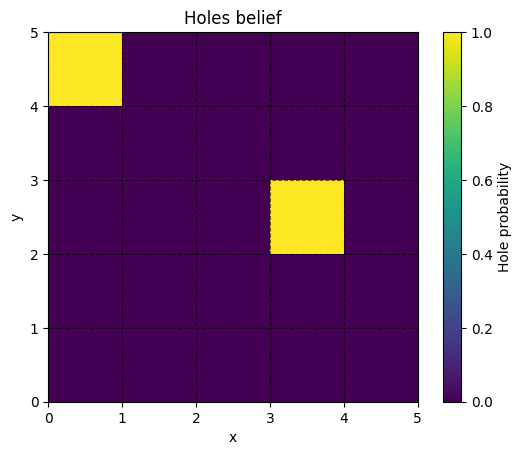

Episode 9:
The game ended in 68 steps with the following outcome: Escaped.
Belief:


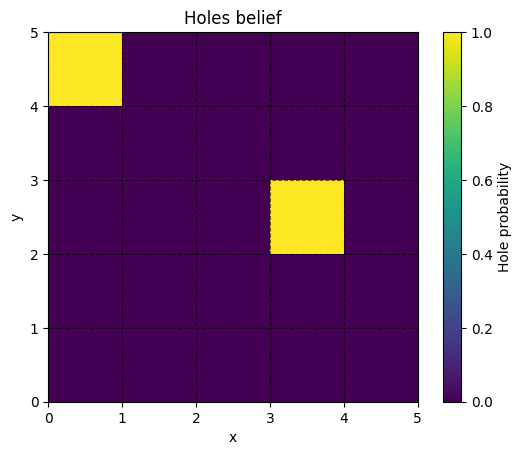

Episode 10:
The game ended in 132 steps with the following outcome: Escaped.
Belief:


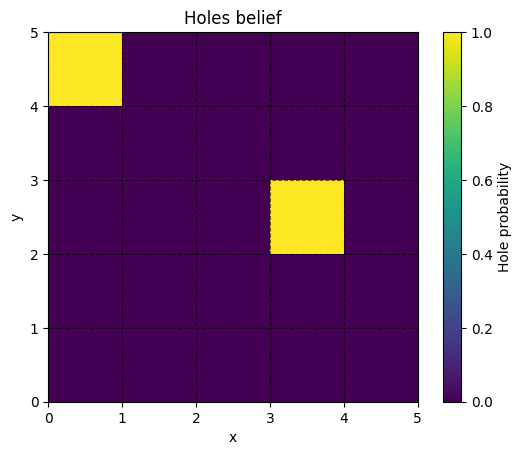

Episode 11:
The game ended in 52 steps with the following outcome: Escaped.
Belief:


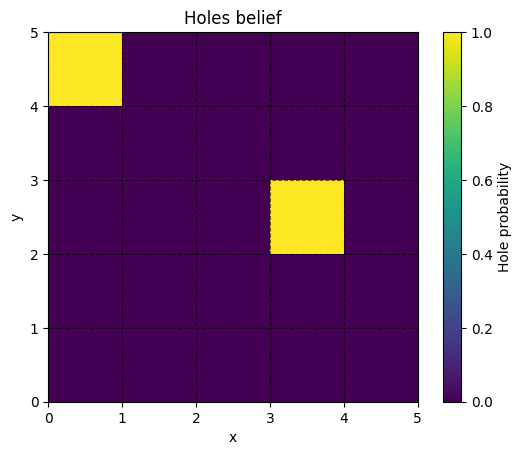

Episode 12:
The game ended in 138 steps with the following outcome: Escaped.
Belief:


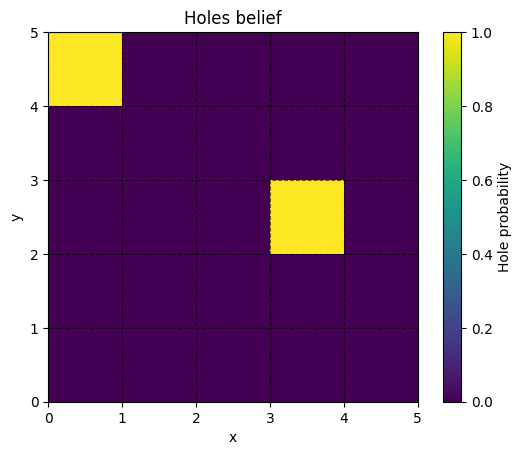

Episode 13:
The game ended in 16 steps with the following outcome: Escaped.
Belief:


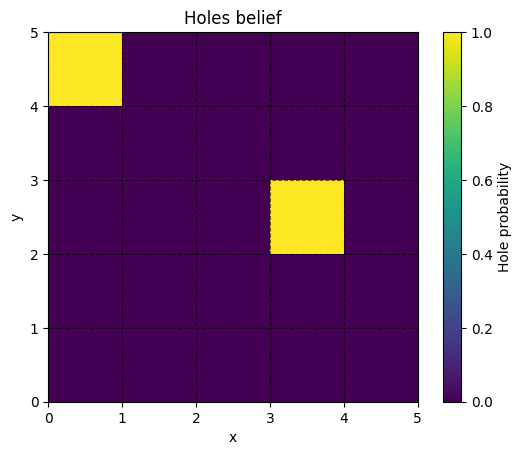

Episode 14:
The game ended in 146 steps with the following outcome: Escaped.
Belief:


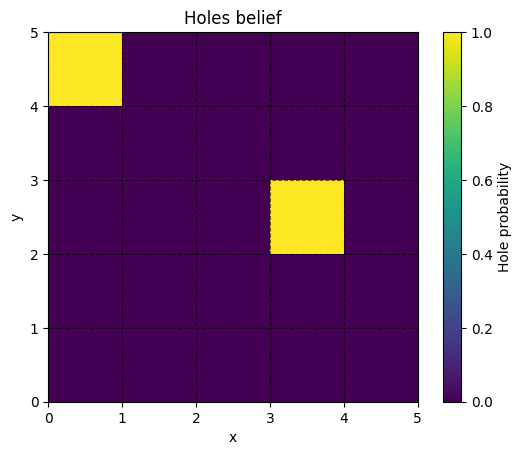

Episode 15:
The game ended in 106 steps with the following outcome: Escaped.
Belief:


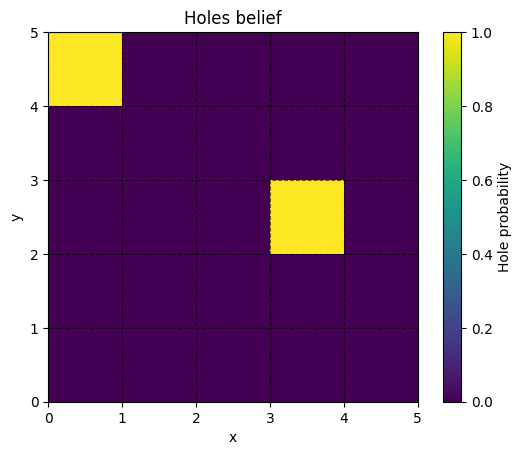

Episode 16:
The game ended in 64 steps with the following outcome: Escaped.
Belief:


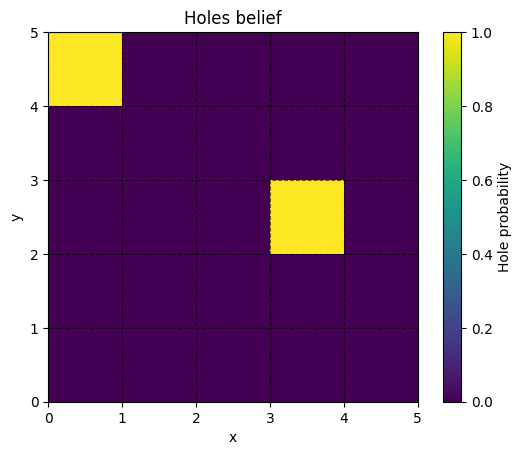

Episode 17:
The game ended in 93 steps with the following outcome: Escaped.
Belief:


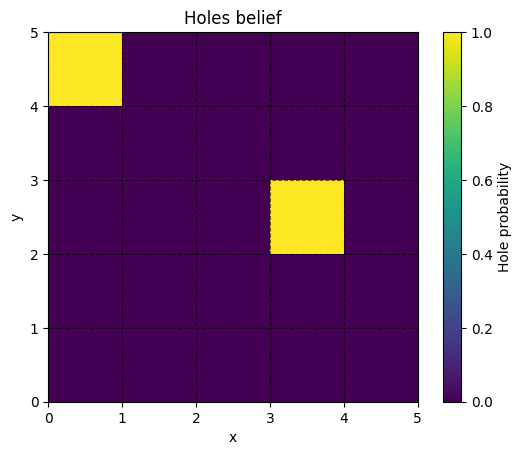

Episode 18:
The game ended in 75 steps with the following outcome: Escaped.
Belief:


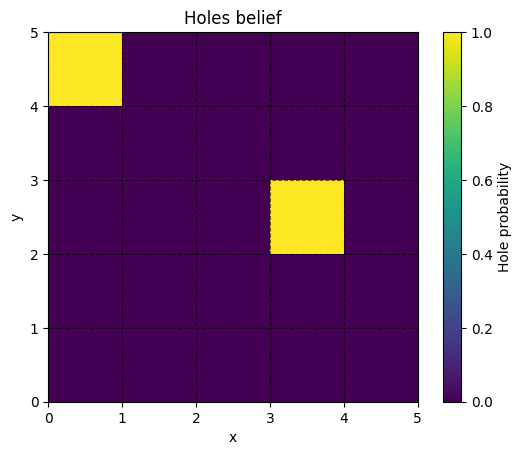

Episode 19:
The game ended in 64 steps with the following outcome: Escaped.
Belief:


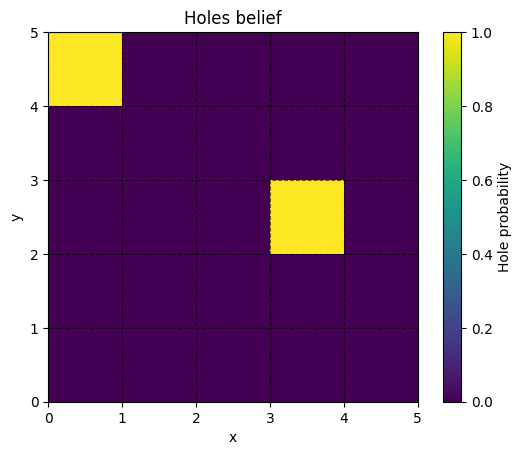

Episode 20:
The game ended in 437 steps with the following outcome: Escaped.
Belief:


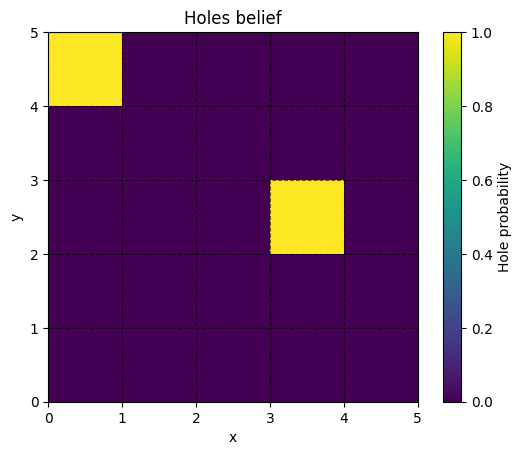

Escaped 20 times


In [70]:
belief_state = BeliefState()

print("Initial belief:")
belief_state.visualise()

escaped = 0

for episode in range(1, 21):
    outcome, trajectory = play_game(smarter_agent, belief_state)
    
    print(f"Episode {episode}:")
    print(f"The game ended in {len(trajectory)} steps with the following outcome: {outcome}.")
    
    print("Belief:")
    belief_state.visualise()

    if outcome == "Escaped":
        escaped += 1

print(f"Escaped {escaped} times")